# Tugas 1-Implementasi Dasar

##### a.	Implementasikan program serial untuk menghitung π dengan metode Monte Carlo
##### b.	Implementasikan versi paralel menggunakan thread/multiprocessing
##### c.	Gunakan num_samples = 10,000,000 untuk konsistensi


## Implementasi Serial

In [13]:
import random
import time
import math

def calculate_pi_serial(num_samples):
    inside_circle = 0
    
    for _ in range(num_samples):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        
        # Cek apakah titik berada dalam lingkaran
        if x**2 + y**2 <= 1:
            inside_circle += 1
    
    pi_estimate = 4 * inside_circle / num_samples
    return pi_estimate

# Testing
if __name__ == "__main__":
    num_samples = 10_000_000
    
    start_time = time.time()
    pi_est = calculate_pi_serial(num_samples)
    end_time = time.time()
    
    print(f"Estimasi π: {pi_est}")
    print(f"Nilai asli π: {math.pi}")
    print(f"Error: {abs(pi_est - math.pi)}")
    print(f"Waktu eksekusi: {end_time - start_time:.4f} detik")


Estimasi π: 3.142418
Nilai asli π: 3.141592653589793
Error: 0.0008253464102070396
Waktu eksekusi: 5.5778 detik


## Implementasi Parallel

In [14]:
import multiprocessing
import random
import time
import math

def monte_carlo_chunk(chunk_size):
    """Menghitung titik dalam lingkaran untuk sejumlah sampel"""
    inside = 0
    for _ in range(chunk_size):
        x = random.uniform(-1, 1)
        y = random.uniform(-1, 1)
        if x**2 + y**2 <= 1:
            inside += 1
    return inside

def calculate_pi_parallel(num_samples, num_processes):
    """Menghitung π menggunakan multiprocessing"""
    chunk_size = num_samples // num_processes
    
    # Buat pool worker
    with multiprocessing.Pool(processes=num_processes) as pool:
        results = pool.map(monte_carlo_chunk, [chunk_size] * num_processes)
    
    total_inside = sum(results)
    pi_estimate = 4 * total_inside / (chunk_size * num_processes)
    return pi_estimate

# Testing dengan berbagai jumlah proses
if __name__ == "__main__":
    num_samples = 10_000_000
    
    for num_procs in [1, 2, 4, 8, 16, 32, 64, 128]:
        start_time = time.time()
        pi_est = calculate_pi_parallel(num_samples, num_procs)
        end_time = time.time()
        
        print(f"\nProses: {num_procs}")
        print(f"  Estimasi π: {pi_est}")
        print(f"  Waktu: {end_time - start_time:.4f} detik")


Proses: 1
  Estimasi π: 3.142448
  Waktu: 5.5866 detik

Proses: 2
  Estimasi π: 3.1413048
  Waktu: 3.2217 detik

Proses: 4
  Estimasi π: 3.1417732
  Waktu: 1.7209 detik

Proses: 8
  Estimasi π: 3.14196
  Waktu: 1.0883 detik

Proses: 16
  Estimasi π: 3.1411328
  Waktu: 0.8938 detik

Proses: 32
  Estimasi π: 3.1419284
  Waktu: 1.2034 detik

Proses: 64
  Estimasi π: 3.142468
  Waktu: 1.5180 detik

Proses: 128
  Estimasi π: 3.1414996
  Waktu: 2.2839 detik


# Tugas 2-Eksperimen dan Analisis

##### Lakukan eksperimen dengan variasi:
#####     -Jumlah thread/process: [1, 2, 4, 8, 16, 32]
#####     -Ukuran sampel: [10M]
##### Catat waktu eksekusi untuk setiap kombinasi dan hitung:
#####     -Speedup=(waktu serial )⁄(waktu paralel)
#####     -Efficiency=speedup⁄(jumlah thread)


# Tugas 3-Visualisasi

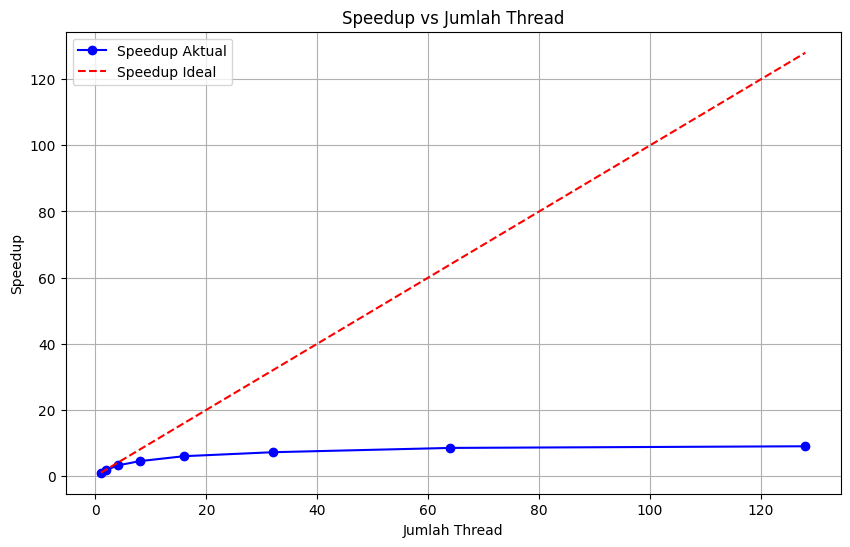

In [15]:
import matplotlib.pyplot as plt

# Data contoh
thread_counts = [1, 2, 4, 8, 16, 32, 64, 128]
speedups = [1.0, 1.8, 3.2, 4.5, 6.0, 7.2, 8.5, 9.0]

plt.figure(figsize=(10, 6))
plt.plot(thread_counts, speedups, 'bo-', label='Speedup Aktual')
plt.plot(thread_counts, thread_counts, 'r--', label='Speedup Ideal')
plt.xlabel('Jumlah Thread')
plt.ylabel('Speedup')
plt.title('Speedup vs Jumlah Thread')
plt.legend()
plt.grid(True)
plt.savefig('speedup_analysis.png')
plt.show()